In [1]:
import os
import sys
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

from src.models.graphgps.model import GraphGPSModel
from src.models.graphformer.model import GraphormerModel

sns.set_theme(style="whitegrid")

In [2]:
CONFIG_PATH = "../config/eap/default.yaml" 

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

def get_model(config):
    if config['model']['architecture'] == 'graphgps':
        return GraphGPSModel(config)
    elif config['model']['architecture'] == 'graphormer':
        return GraphormerModel(config)
    else:
        raise ValueError("Unknown architecture")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_model(config).to(device)

print(f"Model {config['model']['architecture'].upper()} loaded successfully.")

Model GRAPHGPS loaded successfully.


In [3]:
save_dir = config['experiment']['save_dir']
if not os.path.exists(save_dir):
    save_dir = os.path.join("..", save_dir)

masks_path = os.path.join(save_dir, 'optimal_masks.pt')
pareto_path = os.path.join(save_dir, 'pareto_curve_data.pt')

total_params = sum(p.numel() for p in model.parameters())

if os.path.exists(masks_path):
    masks = torch.load(masks_path, map_location='cpu')
    
    prunable_params = sum(mask.numel() for mask in masks.values())
    
    cut_params = sum((mask == 0).sum().item() for mask in masks.values())
    retained_params = prunable_params - cut_params

    print("=== PARAMETER SPARSITY REPORT ===")
    print(f"Total Model Parameters:    {total_params:,}")
    print(f"Total Prunable Parameters: {prunable_params:,} ({(prunable_params/total_params)*100:.1f}% of whole model)")
    print("-" * 33)
    print(f"Parameters Cut (Pruned):   {cut_params:,}")
    print(f"Parameters Retained:       {retained_params:,}")
    print("-" * 33)
    print(f"Sparsity (% of PRUNABLE cut): {(cut_params/prunable_params)*100:.2f}%")
    print(f"Sparsity (% of TOTAL cut):    {(cut_params/total_params)*100:.2f}%")

else:
    print(f"Could not find optimal_masks.pt at {masks_path}. Did the binary search save properly?")

=== PARAMETER SPARSITY REPORT ===
Total Model Parameters:    15,839,618
Total Prunable Parameters: 98,690 (0.6% of whole model)
---------------------------------
Parameters Cut (Pruned):   92,087
Parameters Retained:       6,603
---------------------------------
Sparsity (% of PRUNABLE cut): 93.31%
Sparsity (% of TOTAL cut):    0.58%


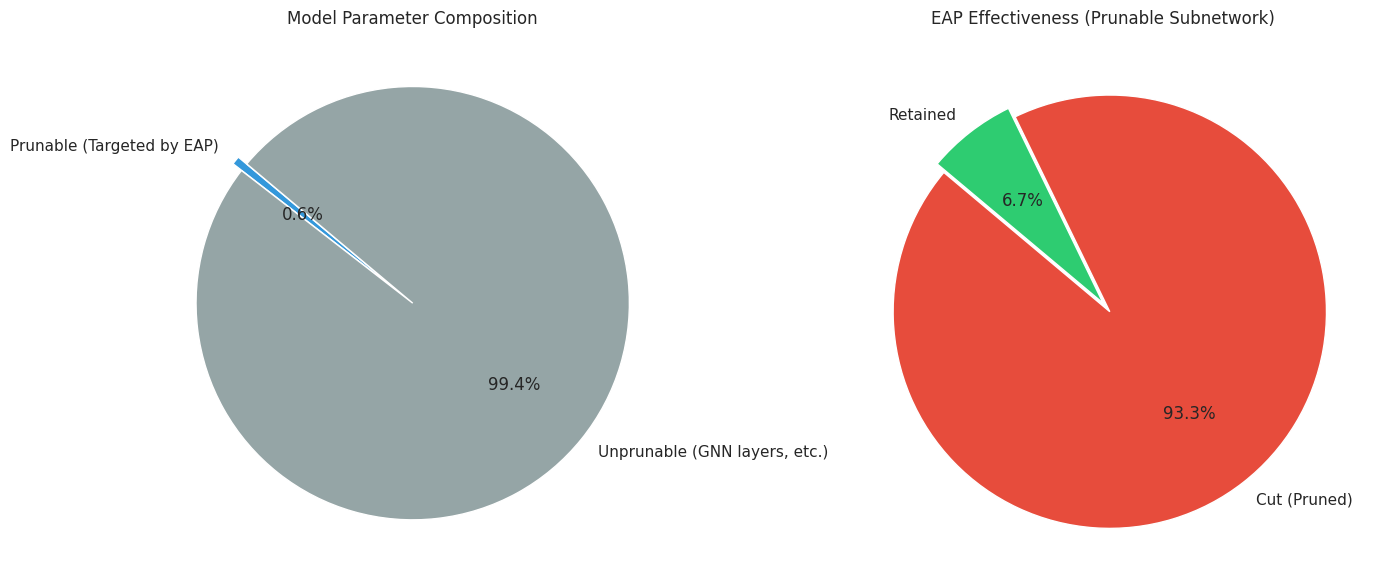

In [4]:
if os.path.exists(masks_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    labels_1 = ['Prunable (Targeted by EAP)', 'Unprunable (GNN layers, etc.)']
    sizes_1 = [prunable_params, total_params - prunable_params]
    colors_1 = ['#3498db', '#95a5a6']
    
    ax1.pie(sizes_1, labels=labels_1, autopct='%1.1f%%', colors=colors_1, startangle=140, explode=(0.05, 0))
    ax1.set_title("Model Parameter Composition")

    labels_2 = ['Cut (Pruned)', 'Retained']
    sizes_2 = [cut_params, retained_params]
    colors_2 = ['#e74c3c', '#2ecc71']
    
    ax2.pie(sizes_2, labels=labels_2, autopct='%1.1f%%', colors=colors_2, startangle=140, explode=(0.05, 0))
    ax2.set_title("EAP Effectiveness (Prunable Subnetwork)")

    plt.tight_layout()
    plt.show()

In [5]:
if os.path.exists(pareto_path):
    pareto_data = torch.load(pareto_path, map_location='cpu')
    
    sparsities = [res['sparsity'] * 100 for res in pareto_data]
    f1_scores = [res['metric'] for res in pareto_data]
    
    plt.figure(figsize=(10, 6))
    plt.plot(sparsities, f1_scores, marker='o', linestyle='-', color='#8e44ad', linewidth=2, markersize=8)
    
    baseline_f1 = f1_scores[0] 
    plt.axhline(y=baseline_f1, color='gray', linestyle='--', label=f'Baseline F1 ({baseline_f1:.4f})')
    
    plt.title("EAP Pareto Curve: Performance vs. Sparsity", fontsize=14)
    plt.xlabel("Sparsity (% of Prunable Params Cut)", fontsize=12)
    plt.ylabel("Macro F1 Score", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    for s, f in zip(sparsities, f1_scores):
        plt.annotate(f"{f:.2f}", (s, f), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        
    plt.show()
else:
    print("No pareto_curve_data.pt found. Run optimizer mode: 'sweep' to generate this plot.")

No pareto_curve_data.pt found. Run optimizer mode: 'sweep' to generate this plot.


In [6]:
import pandas as pd
from IPython.display import display

if os.path.exists(masks_path):
    layer_stats = []
    
    patchable_components = model.get_patchable_components()
    
    for comp_name, module in patchable_components.items():
        if comp_name in masks:
            mask = masks[comp_name]
            
            total_features = mask.numel()
            cut = (mask == 0).sum().item()
            retained = total_features - cut
            sparsity = (cut / total_features) * 100
            
            status = "Targeted (Pruned)" if cut > 0 else "Targeted (Intact)"
            
            layer_stats.append({
                "Component Name": comp_name,
                "Status": status,
                "Total Features": total_features,
                "Cut Features": cut,
                "Retained Features": retained,
                "Sparsity (%)": sparsity
            })
        else:
           
            layer_stats.append({
                "Component Name": comp_name,
                "Status": "Skipped (Unprunable)",
                "Total Features": "N/A",
                "Cut Features": 0,
                "Retained Features": "N/A",
                "Sparsity (%)": 0.0
            })
            
    df_layers = pd.DataFrame(layer_stats)
    
    def highlight_pruned(row):
        if row['Status'] == 'Targeted (Pruned)':
            return ['background-color: #ffebee'] * len(row)
        elif row['Status'] == 'Skipped (Unprunable)':
            return ['color: #7f8c8d'] * len(row)
        return [''] * len(row)
    
    styled_df = df_layers.style.apply(highlight_pruned, axis=1) \
                               .format({"Sparsity (%)": "{:.2f}%", 
                                        "Total Features": "{}", 
                                        "Cut Features": "{}", 
                                        "Retained Features": "{}"}) \
                               .set_caption("Component-by-Component Activation Sparsity Report")
    
    display(styled_df)
    
    print("\n--- Top 5 Most Heavily Pruned Components ---")
    top_pruned = df_layers[df_layers['Cut Features'] > 0].sort_values(by="Sparsity (%)", ascending=False).head(5)
    if not top_pruned.empty:
        display(top_pruned[['Component Name', 'Sparsity (%)', 'Cut Features']])
    else:
        print("No components were pruned!")

else:
    print("Masks not found. Run the EAP binary search first.")

,Component Name,Status,Total Features,Cut Features,Retained Features,Sparsity (%)
0,minar_pe_encoder,Targeted (Pruned),256,256,0,100.00%
1,minar_layer_0_local_mpnn,Targeted (Pruned),256,256,0,100.00%
2,classic_layer_0_global_attn,Targeted (Pruned),5120,5113,7,99.86%
3,classic_layer_0_mlp_linear1,Targeted (Pruned),512,489,23,95.51%
4,classic_layer_0_mlp_linear2,Targeted (Pruned),256,186,70,72.66%
5,minar_layer_1_local_mpnn,Targeted (Pruned),256,256,0,100.00%
6,classic_layer_1_global_attn,Targeted (Pruned),5120,5099,21,99.59%
7,classic_layer_1_mlp_linear1,Targeted (Pruned),512,507,5,99.02%
8,classic_layer_1_mlp_linear2,Targeted (Pruned),256,233,23,91.02%
9,minar_layer_2_local_mpnn,Targeted (Pruned),256,255,1,99.61%



--- Top 5 Most Heavily Pruned Components ---


,Component Name,Sparsity (%),Cut Features
0,minar_pe_encoder,100.0,256
1,minar_layer_0_local_mpnn,100.0,256
5,minar_layer_1_local_mpnn,100.0,256
33,minar_layer_8_local_mpnn,100.0,256
38,classic_layer_9_global_attn,100.0,5120


In [7]:
import pandas as pd
from IPython.display import display

print(f"=== Architecture Overview: {config['model']['architecture'].upper()} ===")

print("\n--- 1. High-Level Module Structure ---")
print(model)

print("\n--- 2. Detailed Parameter Shapes ---")
param_data = []
total_params = 0

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params
    param_data.append({
        "Parameter Name": name,
        "Shape": str(list(param.shape)),
        "Parameter Count": num_params,
        "Trainable": param.requires_grad
    })
    
df_architecture = pd.DataFrame(param_data)

styled_arch = df_architecture.style \
    .format({"Parameter Count": "{:,}"}) \
    .set_caption(f"Total Model Parameters: {total_params:,}") \
    .set_properties(**{'text-align': 'left'})

display(styled_arch)

=== Architecture Overview: GRAPHGPS ===

--- 1. High-Level Module Structure ---
GraphGPSModel(
  (encoder): FeatureEncoder(
    (node_encoder): Linear(in_features=10, out_features=256, bias=True)
    (pe_encoder): Linear(in_features=20, out_features=256, bias=True)
  )
  (layers): ModuleList(
    (0-15): 16 x GPSConv(256, conv=ResGatedGraphConv(256, 256), heads=8, attn_type=multihead)
  )
  (head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

--- 2. Detailed Parameter Shapes ---


,Parameter Name,Shape,Parameter Count,Trainable
0,encoder.node_encoder.weight,"[256, 10]","2,560",True
1,encoder.node_encoder.bias,[256],256,True
2,encoder.pe_encoder.weight,"[256, 20]","5,120",True
3,encoder.pe_encoder.bias,[256],256,True
4,layers.0.conv.bias,[256],256,True
5,layers.0.conv.lin_key.weight,"[256, 512]","131,072",True
6,layers.0.conv.lin_key.bias,[256],256,True
7,layers.0.conv.lin_query.weight,"[256, 512]","131,072",True
8,layers.0.conv.lin_query.bias,[256],256,True
9,layers.0.conv.lin_value.weight,"[256, 512]","131,072",True


In [8]:
import pandas as pd
from IPython.display import display

total_model_params = sum(p.numel() for p in model.parameters())

all_components = model.get_patchable_components()
classic_targeted_modules = {k: v for k, v in all_components.items() if 'classic_' in k}
minar_ignored_modules = {k: v for k, v in all_components.items() if 'classic_' not in k}

def count_actual_params(module_dict):
    seen_params = set()
    total = 0
    for mod in module_dict.values():
        for p in mod.parameters():
            if p not in seen_params:
                total += p.numel()
                seen_params.add(p)
    return total

eap_accessible_params = count_actual_params(classic_targeted_modules)
minar_known_ignored = count_actual_params(minar_ignored_modules)

unlisted_ignored = total_model_params - (eap_accessible_params + minar_known_ignored)
total_off_limits = minar_known_ignored + unlisted_ignored

# 4. Display the results clearly
summary_data = [
    {
        "Category": "EAP Accessible (Classic Modules)",
        "Description": "Weights/Biases in layers EAP can proxy-prune",
        "Parameter Count": eap_accessible_params,
        "% of Total Model": (eap_accessible_params / total_model_params) * 100
    },
    {
        "Category": "Off-Limits: Minar Modules",
        "Description": "Local MPNNs and GNN-specific encoders",
        "Parameter Count": minar_known_ignored,
        "% of Total Model": (minar_known_ignored / total_model_params) * 100
    },
    {
        "Category": "Off-Limits: Unlisted / Architecture",
        "Description": "Embeddings, Norms, Pooling, unhooked biases",
        "Parameter Count": unlisted_ignored,
        "% of Total Model": (unlisted_ignored / total_model_params) * 100
    }
]

df_param_split = pd.DataFrame(summary_data)
display(df_param_split)

print("\n=== THE BOTTOM LINE ===")
print(f"Classic EAP is effectively controlling {eap_accessible_params:,} parameters.")
print(f"It is completely blind to {total_off_limits:,} parameters.")

,Category,Description,Parameter Count,% of Total Model
0,EAP Accessible (Classic Modules),Weights/Biases in layers EAP can proxy-prune,8450434,53.349986
1,Off-Limits: Minar Modules,Local MPNNs and GNN-specific encoders,7361792,46.477080
2,Off-Limits: Unlisted / Architecture,"Embeddings, Norms, Pooling, unhooked biases",27392,0.172933



=== THE BOTTOM LINE ===
Classic EAP is effectively controlling 8,450,434 parameters.
It is completely blind to 7,389,184 parameters.


In [9]:
estimated_cut_params = int((cut_params / prunable_params) * eap_accessible_params)

print("=== ACTIVATION SPARSITY REPORT ===")
print(f"Total Model Weight Parameters:    {total_params:,}")
print(f"EAP-Controlled Weight Parameters: {eap_accessible_params:,}")
print("-" * 38)
print(f"Total Activation Features (Masks): {prunable_params:,}")
print(f"Activation Features Cut:           {cut_params:,}")
print(f"Activation Features Retained:      {retained_params:,}")
print("-" * 38)
print(f"Feature Sparsity:                  {(cut_params/prunable_params)*100:.2f}%")
print(f"Estimated Weights Pruned:          ~{estimated_cut_params:,} ({(estimated_cut_params/total_params)*100:.2f}% of total model)")

=== ACTIVATION SPARSITY REPORT ===
Total Model Weight Parameters:    15,839,618
EAP-Controlled Weight Parameters: 8,450,434
--------------------------------------
Total Activation Features (Masks): 98,690
Activation Features Cut:           92,087
Activation Features Retained:      6,603
--------------------------------------
Feature Sparsity:                  93.31%
Estimated Weights Pruned:          ~7,885,045 (49.78% of total model)


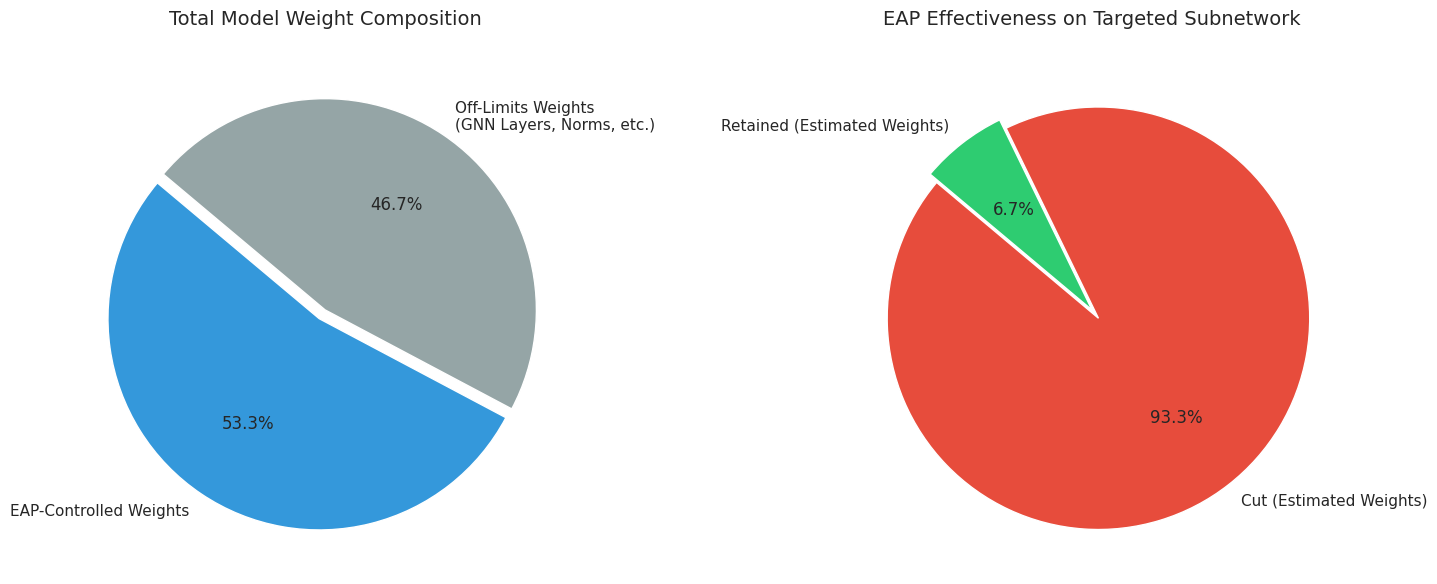

In [10]:
import os
import matplotlib.pyplot as plt

if os.path.exists(masks_path):
    estimated_retained_params = eap_accessible_params - estimated_cut_params
    unprunable_weight_params = total_params - eap_accessible_params

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    labels_1 = ['EAP-Controlled Weights', 'Off-Limits Weights\n(GNN Layers, Norms, etc.)']
    sizes_1 = [eap_accessible_params, unprunable_weight_params]
    colors_1 = ['#3498db', '#95a5a6']
    
    ax1.pie(sizes_1, labels=labels_1, autopct='%1.1f%%', colors=colors_1, startangle=140, explode=(0.05, 0))
    ax1.set_title("Total Model Weight Composition", fontsize=14, pad=15)

    labels_2 = ['Cut (Estimated Weights)', 'Retained (Estimated Weights)']
    sizes_2 = [estimated_cut_params, estimated_retained_params]
    colors_2 = ['#e74c3c', '#2ecc71']
    
    ax2.pie(sizes_2, labels=labels_2, autopct='%1.1f%%', colors=colors_2, startangle=140, explode=(0.05, 0))
    ax2.set_title("EAP Effectiveness on Targeted Subnetwork", fontsize=14, pad=15)

    plt.tight_layout()
    plt.show()